# Entrenamiento de modelo de predicción de puntuación


## Importación de librerias necesarias


In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")


JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [3]:
import numpy as np
import pandas as pd
import sys
import os
import shutil
import tensorflow as tf
import tensorflow_io as tfio
from pyspark.sql import functions as F, types as T, DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.ml.feature import VectorAssembler


2025-11-15 12:31:44.908472: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-15 12:31:44.921553: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-15 12:31:44.925501: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-15 12:31:44.935072: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-15 12:31:47.168443: W tensorflow/compiler/tf2

In [4]:
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA built: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU memory growth error: {e}")

if gpus:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[2.0, 0.0], [0.0, 2.0]])
        c = tf.matmul(a, b)
        print(f"GPU test result: {c.numpy()}")
        print("✓ GPU is working!")
else:
    print("❌ No GPU detected")


Python executable: /mnt/d/Maestría/Amazon Reviews Code/.venv-linux/bin/python
Python version: 3.11.13 (main, Jun  4 2025, 08:57:30) [GCC 13.3.0]
TensorFlow version: 2.17.1
CUDA built: True
GPU devices: []
❌ No GPU detected


I0000 00:00:1763227912.650494  349830 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-11-15 12:31:52.690039: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [ ]:
from src.utils.spark import SparkUtils, METASTORE_PATH
spark_utils = SparkUtils('predict_category_model')
spark = spark_utils.spark


:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-3d4eb6ad-d84e-4f4a-bd5a-eed8b2a38f7d;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 125ms :: artifacts dl 4ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   

## Cargar datos fuente de entrenamiento


In [6]:
GOLD_ENCODING = 'gold.encoding'
GOLD_PREMODELING = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
SCHEMA = 'silver.preprocess'


In [7]:
REGENERATE_MODEL = True


In [8]:
src_dir_boolean = f"{METASTORE_PATH}/warehouse/gold.premodeling/final_training_data_rating_array_boolean"
dst_dir_boolean = f"{METASTORE_PATH}/warehouse/gold.premodeling/dataset_score_model_boolean"
dst_path_boolean = os.path.join(dst_dir_boolean, "dataset_training.parquet")


In [9]:
from src.utils.models import BinaryModel

In [10]:
binary_model = BinaryModel('binary_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")

In [14]:
from src.utils.models import BinaryModel
binary_model = BinaryModel('binary_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")
binary_model.input_shape = 314
binary_model.create_model()
binary_model.plot_model(
    save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/binary_model2.png"
)

model plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model2.png


'/mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model2.png'

In [27]:
binary_model.prepare_data(
    spark, src_dir_boolean, target_columns=[b"rating_boolean"], shuffle_buffer_size = -1,
    train_ratio=0.8, val_ratio=0.1
)


Files count: 10
Reading file: /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/final_training_data_rating_array_boolean/part-00001-ad13b737-b8d2-4374-b6f1-fe69d8b712c3-c000.snappy.parquet
Reading file: /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/final_training_data_rating_array_boolean/part-00000-ad13b737-b8d2-4374-b6f1-fe69d8b712c3-c000.snappy.parquet
Reading file: /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/final_training_data_rating_array_boolean/part-00002-ad13b737-b8d2-4374-b6f1-fe69d8b712c3-c000.snappy.parquet
Reading file: /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/final_training_data_rating_array_boolean/part-00003-ad13b737-b8d2-4374-b6f1-fe69d8b712c3-c000.snappy.parquet
Reading file: /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/final_training_data_rating_array_boolean/part-00004-ad13b737-b8d2-4374-b6f1-fe69d8b712c3-c000.snappy.parquet
Reading file: /mnt/d/Maestría

## Crear modelo de predicción


In [30]:
binary_model.create_model()


<Sequential name=sequential_2, built=True>

In [ ]:
binary_model.plot_model(
    save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/binary_model.png"
)

Improved tiered model plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model.png


'/mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/binary_model.png'

In [14]:
binary_model.model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_0 (Dense)                 │ (None, 256)            │        96,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,777 (546.00 KB)

 Trainable params: 139,777 (546.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
if True:
    history_model_binary = binary_model.train(epochs=20)


Epoch 1/20


I0000 00:00:1762232464.453674 1472462 service.cc:146] XLA service 0x79dcec0143b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762232464.453696 1472462 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050, Compute Capability 8.6
2025-11-04 00:01:04.480146: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-04 00:01:04.628039: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


     10/Unknown 14s 21ms/step - accuracy: 0.8103 - loss: 0.6151

I0000 00:00:1762232466.057168 1472462 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    455/Unknown 35s 47ms/step - accuracy: 0.7679 - loss: 0.5917

2025-11-04 00:01:27.440604: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-11-04 00:01:27.440626: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_4]]
2025-11-04 00:01:27.440642: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 10086181493417619041
2025-11-04 00:01:27.440653: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 921426363624600330
/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.r

KeyboardInterrupt: 

2025/11/03 23:47:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/03 23:47:56 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/11/03 23:48:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


da62db697dc14ee896de1a84588f60ce
Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_binary_model.png


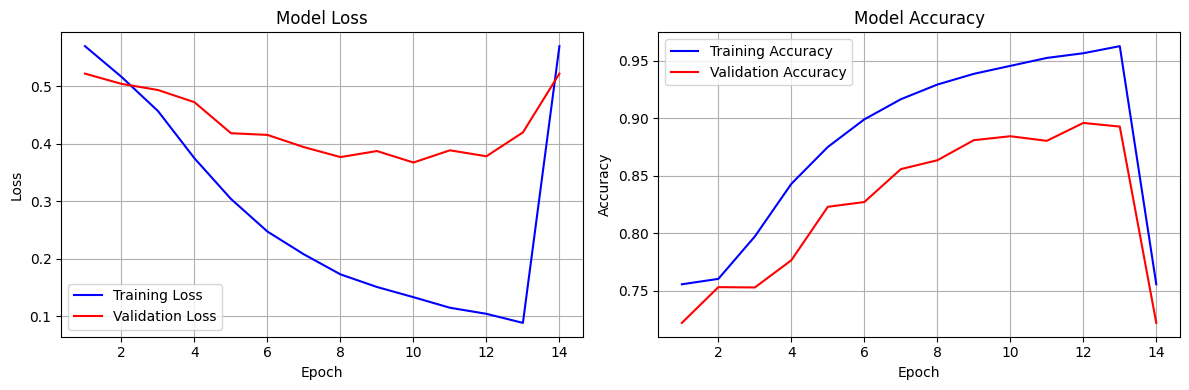

In [ ]:
if True:
    for name, model in [
        ("binary_model", binary_model)
    ]:

        tags = {
            "model_type": "neural_network",
            "task": "rating_prediction",
            "dataset": "amazon_reviews",
            "variant": name
        }
 
        exp = model.log_training_history(
            run_name=f"{name}_{model.input_shape}features",
            tags=tags
        )

        print(exp)

        _ = model.plot_training_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_{name}.png"
        )


## Cargar modelo


In [ ]:
from src.utils.models import BinaryModel
binary_model = BinaryModel('binary_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")
binary_model.load_latest_model()


/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
binary_model.list_available_models()



Available Model Versions (filtered by: binary_model)

1. Run ID: da62db697dc14ee896de1a84588f60ce
   Run Name: binary_model_376features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-11-04 04:47:56.442000+00:00
   End Time: 2025-11-04 04:48:10.334000+00:00
   Metrics: Loss: 0.0883, Val Loss: 0.4196, Accuracy: 0.9625, Val Accuracy: 0.8926

2. Run ID: 3d22f578699344afbf70825e7d74c9dc
   Run Name: binary_model_401features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-27 02:21:00.431000+00:00
   End Time: 2025-10-27 02:21:14.596000+00:00
   Metrics: Loss: 0.0650, Val Loss: 0.0420, Accuracy: 0.9717, Val Accuracy: 0.9831

3. Run ID: 195df4651b0e4630bb7a59963e15babe
   Run Name: binary_model_1025features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-20 01:24:18.123000+00:00
   End Time: 2025-10-20 01:24:32.448000+00:00
   Metrics: Loss: 0.5044, Val Loss: 0.6257, Accuracy: 0.7702, Val Accuracy: 0.7181

4. Run ID: da3b31aaa4664d86a48d473d0d937d68
   Run Name: